# Wind Turbine Scada Performance Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
from tensorflow.keras.applications import VGG16
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import classification_report, confusion_matrix
import cv2
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import MultiLabelBinarizer
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import img_to_array
from datasets import load_dataset
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
file_path = r"D:\Novintix\T1.csv" 
df = pd.read_csv(file_path)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Shape: (50530, 5)

Columns: ['Date/Time', 'LV ActivePower (kW)', 'Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']

First few rows:


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645904,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


In [3]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'], dayfirst=True)
df = df.sort_values('Date/Time').reset_index(drop=True)
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(df.info())
print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)
print(df.isnull().sum())
print("\n" + "=" * 80)
print("BASIC STATISTICS")
print("=" * 80)
display(df.describe())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date/Time                      50530 non-null  datetime64[ns]
 1   LV ActivePower (kW)            50530 non-null  float64       
 2   Wind Speed (m/s)               50530 non-null  float64       
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64       
 4   Wind Direction (°)             50530 non-null  float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 1.9 MB
None

MISSING VALUES
Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

BASIC STATISTICS


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530,50530.000000,50530.000000,50530.000000,50530.000000
mean,2018-07-01 20:01:30.065307648,1307.684332,7.557952,1492.175463,123.687559
min,2018-01-01 00:00:00,-2.471405,0.000000,0.000000,0.000000
25%,2018-04-03 05:22:30,50.677890,4.201395,161.328167,49.315437
50%,2018-06-30 16:15:00,825.838074,7.104594,1063.776282,73.712978
75%,2018-09-26 18:57:30,2482.507568,10.300020,2964.972462,201.696720
max,2018-12-31 23:50:00,3618.732910,25.206011,3600.000000,359.997589
std,NaN,1312.459242,4.227166,1368.018238,93.443736


#

## TASK 1: EXPLORATORY DATA ANALYSIS (EDA)

### Task 1.1 - Time Series Trends for All Parameters and Identify Missing and Abnormal Readings


TASK 1: EXPLORATORY DATA ANALYSIS


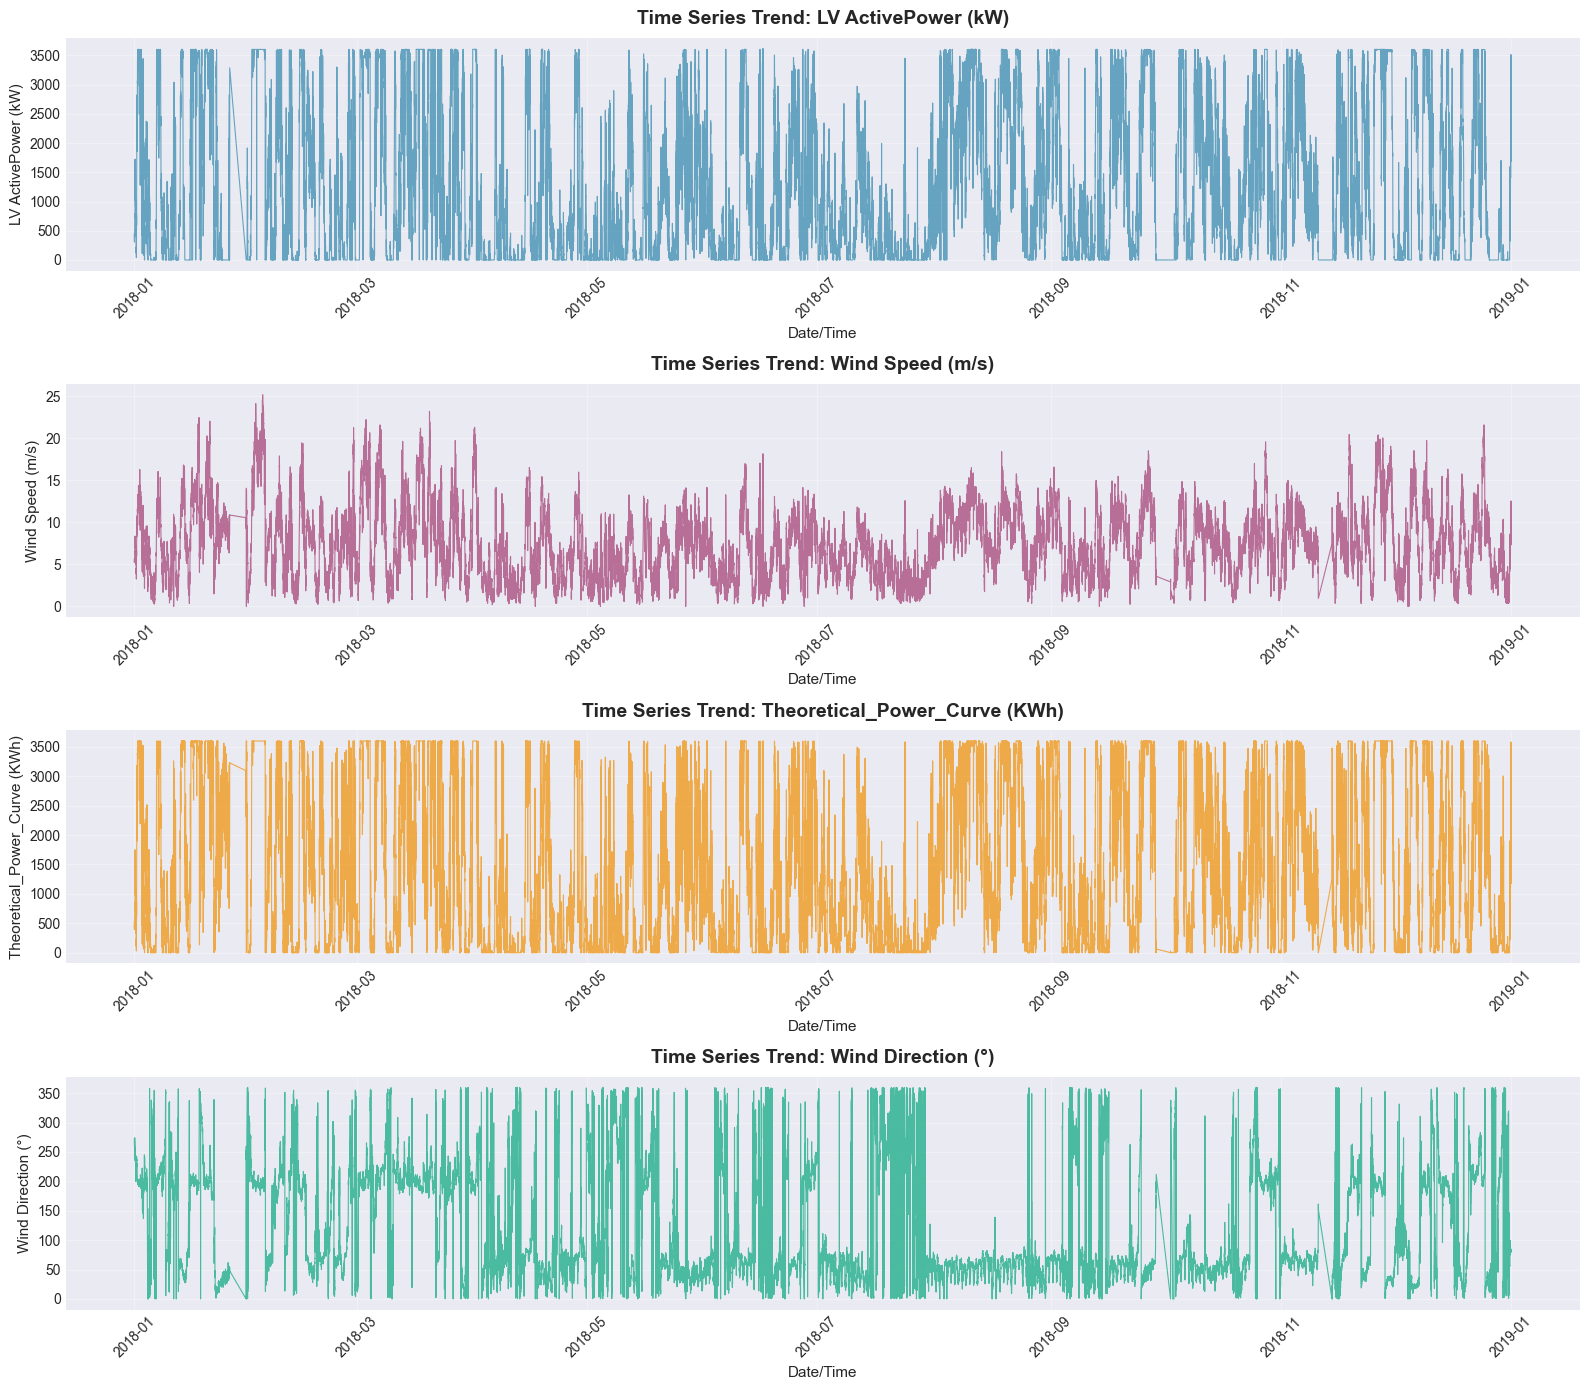

In [4]:
print("\n" + "=" * 80)
print("TASK 1: EXPLORATORY DATA ANALYSIS")
print("=" * 80)
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
parameters = ['LV ActivePower (kW)', 'Wind Speed (m/s)', 
              'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
for idx, (param, color) in enumerate(zip(parameters, colors)):
    axes[idx].plot(df['Date/Time'], df[param], linewidth=0.8, alpha=0.7, color=color)
    axes[idx].set_title(f'Time Series Trend: {param}', fontsize=14, fontweight='bold', pad=10)
    axes[idx].set_xlabel('Date/Time', fontsize=11)
    axes[idx].set_ylabel(param, fontsize=11)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('task1_timeseries_trends.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
print("\n" + "-" * 80)
print("MISSING VALUES ANALYSIS")
print("-" * 80)
missing_summary = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Percentage': missing_percentage
})
print(missing_df)
print("\n" + "-" * 80)
print("ABNORMAL READINGS DETECTION (IQR Method)")
print("-" * 80)
outlier_summary = []
for param in parameters:
    Q1 = df[param].quantile(0.25)
    Q3 = df[param].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[param] < lower_bound) | (df[param] > upper_bound)]
    outlier_summary.append({
        'Parameter': param,
        'Outliers Count': len(outliers),
        'Outliers %': f"{len(outliers)/len(df)*100:.2f}%",
        'Min Value': f"{df[param].min():.2f}",
        'Max Value': f"{df[param].max():.2f}",
        'Expected Min': f"{lower_bound:.2f}",
        'Expected Max': f"{upper_bound:.2f}"
    })
outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)


--------------------------------------------------------------------------------
MISSING VALUES ANALYSIS
--------------------------------------------------------------------------------
                               Missing Count  Percentage
Date/Time                                  0         0.0
LV ActivePower (kW)                        0         0.0
Wind Speed (m/s)                           0         0.0
Theoretical_Power_Curve (KWh)              0         0.0
Wind Direction (°)                         0         0.0

--------------------------------------------------------------------------------
ABNORMAL READINGS DETECTION (IQR Method)
--------------------------------------------------------------------------------


,Parameter,Outliers Count,Outliers %,Min Value,Max Value,Expected Min,Expected Max
0,LV ActivePower (kW),0,0.00%,-2.47,3618.73,-3597.07,6130.25
1,Wind Speed (m/s),423,0.84%,0.00,25.21,-4.95,19.45
2,Theoretical_Power_Curve (KWh),0,0.00%,0.00,3600.00,-4044.14,7170.44
3,Wind Direction (°),0,0.00%,0.00,360.00,-179.26,430.27


### Task 1.2 - Wind Speed vs LV ActivePower Scatter Plot


--------------------------------------------------------------------------------
POWER CURVE ANALYSIS
--------------------------------------------------------------------------------


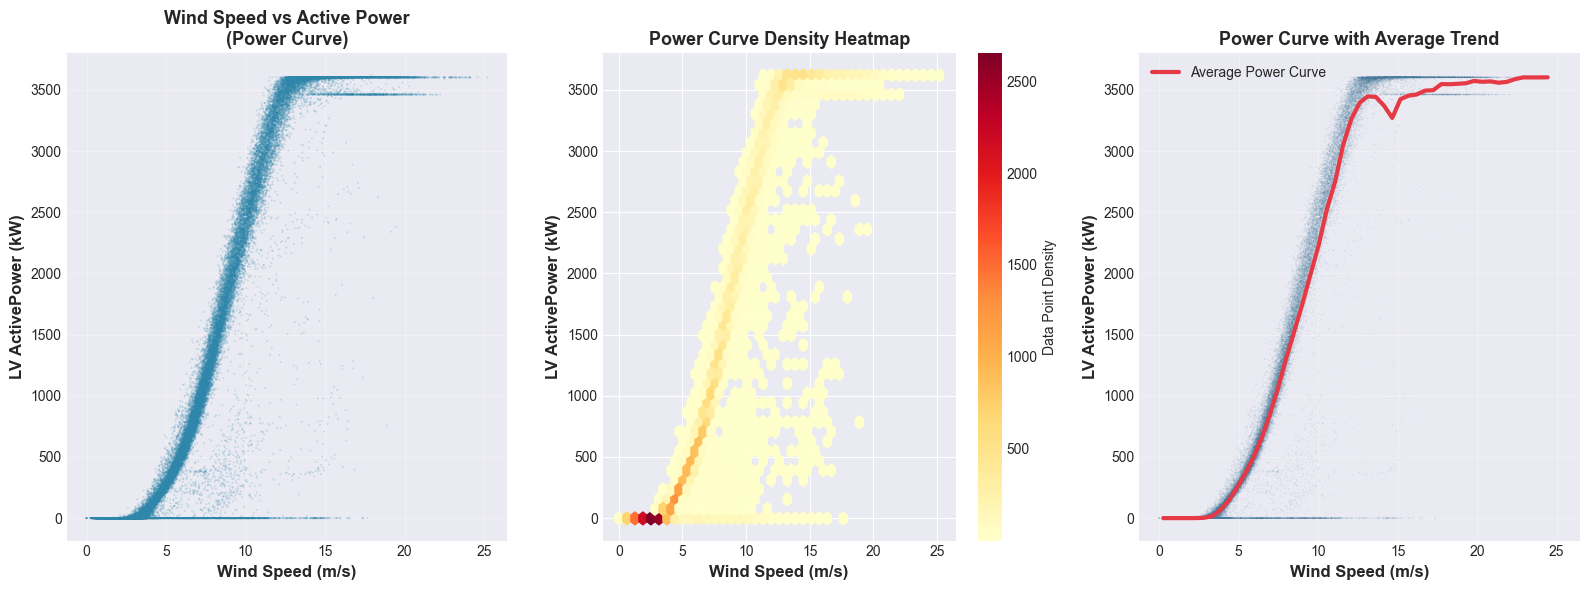

In [6]:
print("\n" + "-" * 80)
print("POWER CURVE ANALYSIS")
print("-" * 80)
fig = plt.figure(figsize=(16, 6))
ax1 = plt.subplot(1, 3, 1)
plt.scatter(df['Wind Speed (m/s)'], df['LV ActivePower (kW)'], 
            alpha=0.2, s=2, c='#2E86AB', edgecolors='none')
plt.xlabel('Wind Speed (m/s)', fontsize=12, fontweight='bold')
plt.ylabel('LV ActivePower (kW)', fontsize=12, fontweight='bold')
plt.title('Wind Speed vs Active Power\n(Power Curve)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
ax2 = plt.subplot(1, 3, 2)
hexbin = plt.hexbin(df['Wind Speed (m/s)'], df['LV ActivePower (kW)'], 
                     gridsize=40, cmap='YlOrRd', mincnt=1)
plt.colorbar(hexbin, label='Data Point Density')
plt.xlabel('Wind Speed (m/s)', fontsize=12, fontweight='bold')
plt.ylabel('LV ActivePower (kW)', fontsize=12, fontweight='bold')
plt.title('Power Curve Density Heatmap', fontsize=13, fontweight='bold')
ax3 = plt.subplot(1, 3, 3)
wind_bins = np.linspace(df['Wind Speed (m/s)'].min(), df['Wind Speed (m/s)'].max(), 50)
power_means = []
wind_centers = []
for i in range(len(wind_bins)-1):
    mask = (df['Wind Speed (m/s)'] >= wind_bins[i]) & (df['Wind Speed (m/s)'] < wind_bins[i+1])
    if mask.sum() > 0:
        power_means.append(df.loc[mask, 'LV ActivePower (kW)'].mean())
        wind_centers.append((wind_bins[i] + wind_bins[i+1]) / 2)

plt.plot(wind_centers, power_means, linewidth=3, color='#E63946', label='Average Power Curve')
plt.scatter(df['Wind Speed (m/s)'], df['LV ActivePower (kW)'], 
            alpha=0.1, s=1, c='#457B9D', edgecolors='none')
plt.xlabel('Wind Speed (m/s)', fontsize=12, fontweight='bold')
plt.ylabel('LV ActivePower (kW)', fontsize=12, fontweight='bold')
plt.title('Power Curve with Average Trend', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task1_power_curve_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

#

## TASK 2: SUPERVISED LEARNING (TIME SERIES FORECASTING)

### Task 2.1 - Prepare Time Series Data

In [7]:
forecast_features = ['LV ActivePower (kW)', 'Wind Speed (m/s)', 
                     'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']
df_forecast = df[forecast_features].copy()
df_forecast = df_forecast.fillna(method='ffill').fillna(method='bfill')
print(f"Forecasting dataset shape: {df_forecast.shape}")
print(f"\nFeatures: {forecast_features}")
print(f"\nFirst few rows:")
df_forecast.head()

Forecasting dataset shape: (50530, 4)

Features: ['LV ActivePower (kW)', 'Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']

First few rows:


,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,380.047791,5.311336,416.328908,259.994904
1,453.769196,5.672167,519.917511,268.641113
2,306.376587,5.216037,390.900016,272.564789
3,419.645904,5.659674,516.127569,271.258087
4,380.650696,5.577941,491.702972,265.674286


### Task 2.2 - Create Windowed Dataset Function

In [8]:
def create_windowed_dataset(data, window_size=24, horizon=1):
    """
    Create windowed time series data for forecasting
    
    Parameters:
    - data: numpy array of time series data
    - window_size: number of past time steps to use
    - horizon: number of future time steps to predict
    
    Returns:
    - X: input sequences
    - y: target values
    """
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:(i + window_size)])
        y.append(data[i + window_size:(i + window_size + horizon)])
    return np.array(X), np.array(y)
WINDOW_SIZE = 24  
HORIZON = 1       
TEST_SIZE = 0.2
print(f"Window size: {WINDOW_SIZE}")
print(f"Forecast horizon: {HORIZON}")
print(f"Test size: {TEST_SIZE}")

Window size: 24
Forecast horizon: 1
Test size: 0.2


In [9]:
models = {}
scalers = {}
results = {}
for feature in forecast_features:
    print(f"\n{'='*60}")
    print(f"Training model for: {feature}")
    print(f"{'='*60}")
    data = df_forecast[feature].values.reshape(-1, 1)    
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)
    scalers[feature] = scaler    
    X, y = create_windowed_dataset(data_scaled, WINDOW_SIZE, HORIZON)    
    split_idx = int(len(X) * (1 - TEST_SIZE))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]  
    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")    
    model = Sequential([
        LSTM(64, activation='relu', return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
        Dropout(0.2),
        LSTM(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(HORIZON)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_train_inv = scaler.inverse_transform(y_pred_train.reshape(-1, 1))
    y_pred_test_inv = scaler.inverse_transform(y_pred_test.reshape(-1, 1))
    train_mse = mean_squared_error(y_train_inv, y_pred_train_inv)
    train_mae = mean_absolute_error(y_train_inv, y_pred_train_inv)
    train_r2 = r2_score(y_train_inv, y_pred_train_inv)
    test_mse = mean_squared_error(y_test_inv, y_pred_test_inv)
    test_mae = mean_absolute_error(y_test_inv, y_pred_test_inv)
    test_r2 = r2_score(y_test_inv, y_pred_test_inv)
    print(f"\nTraining Metrics:")
    print(f"  MSE: {train_mse:.4f}")
    print(f"  MAE: {train_mae:.4f}")
    print(f"  R2 Score: {train_r2:.4f}")
    print(f"\nTest Metrics:")
    print(f"  MSE: {test_mse:.4f}")
    print(f"  MAE: {test_mae:.4f}")
    print(f"  R2 Score: {test_r2:.4f}")
    models[feature] = model
    results[feature] = {
        'history': history,
        'y_train': y_train_inv,
        'y_test': y_test_inv,
        'y_pred_train': y_pred_train_inv,
        'y_pred_test': y_pred_test_inv,
        'train_mse': train_mse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_mse': test_mse,
        'test_mae': test_mae,
        'test_r2': test_r2
    }


Training model for: LV ActivePower (kW)
X_train shape: (40404, 24, 1)
X_test shape: (10102, 24, 1)
Epoch 1/50
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 0.0298 - mae: 0.1043 - val_loss: 0.0062 - val_mae: 0.0571
Epoch 2/50
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0090 - mae: 0.0607 - val_loss: 0.0075 - val_mae: 0.0625
Epoch 3/50
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0069 - mae: 0.0529 - val_loss: 0.0077 - val_mae: 0.0635
Epoch 4/50
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0064 - mae: 0.0487 - val_loss: 0.0099 - val_mae: 0.0729
Epoch 5/50
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0060 - mae: 0.0470 - val_loss: 0.0083 - val_mae: 0.0654
Epoch 6/50
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0058 - mae: 0.0461 - val_loss: 0.0097 - val_mae: 0.0725
Epoch 7/50
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0056 - mae: 0.0449 - val_loss: 0.0096 - val_mae: 0.0720
Epoch 8/50
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 11s 

In [10]:
summary_data = []
for feature in forecast_features:
    summary_data.append({
        'Feature': feature,
        'Train MSE': results[feature]['train_mse'],
        'Train MAE': results[feature]['train_mae'],
        'Train R²': results[feature]['train_r2'],
        'Test MSE': results[feature]['test_mse'],
        'Test MAE': results[feature]['test_mae'],
        'Test R²': results[feature]['test_r2']
    })
summary_df = pd.DataFrame(summary_data)
print("\nModel Performance Summary:")
summary_df


Model Performance Summary:


,Feature,Train MSE,Train MAE,Train R²,Test MSE,Test MAE,Test R²
0,LV ActivePower (kW),96105.072508,204.058322,0.943327,87777.059068,211.592915,0.951261
1,Wind Speed (m/s),1.110652,0.785957,0.937134,1.171659,0.832714,0.936094
2,Theoretical_Power_Curve (KWh),96504.143322,237.450049,0.948311,102558.271260,251.204891,0.944835
3,Wind Direction (°),1326.072577,14.552960,0.850743,1263.696115,13.446671,0.843165


### Task 2.4 - Plot Predicted vs Actual Values

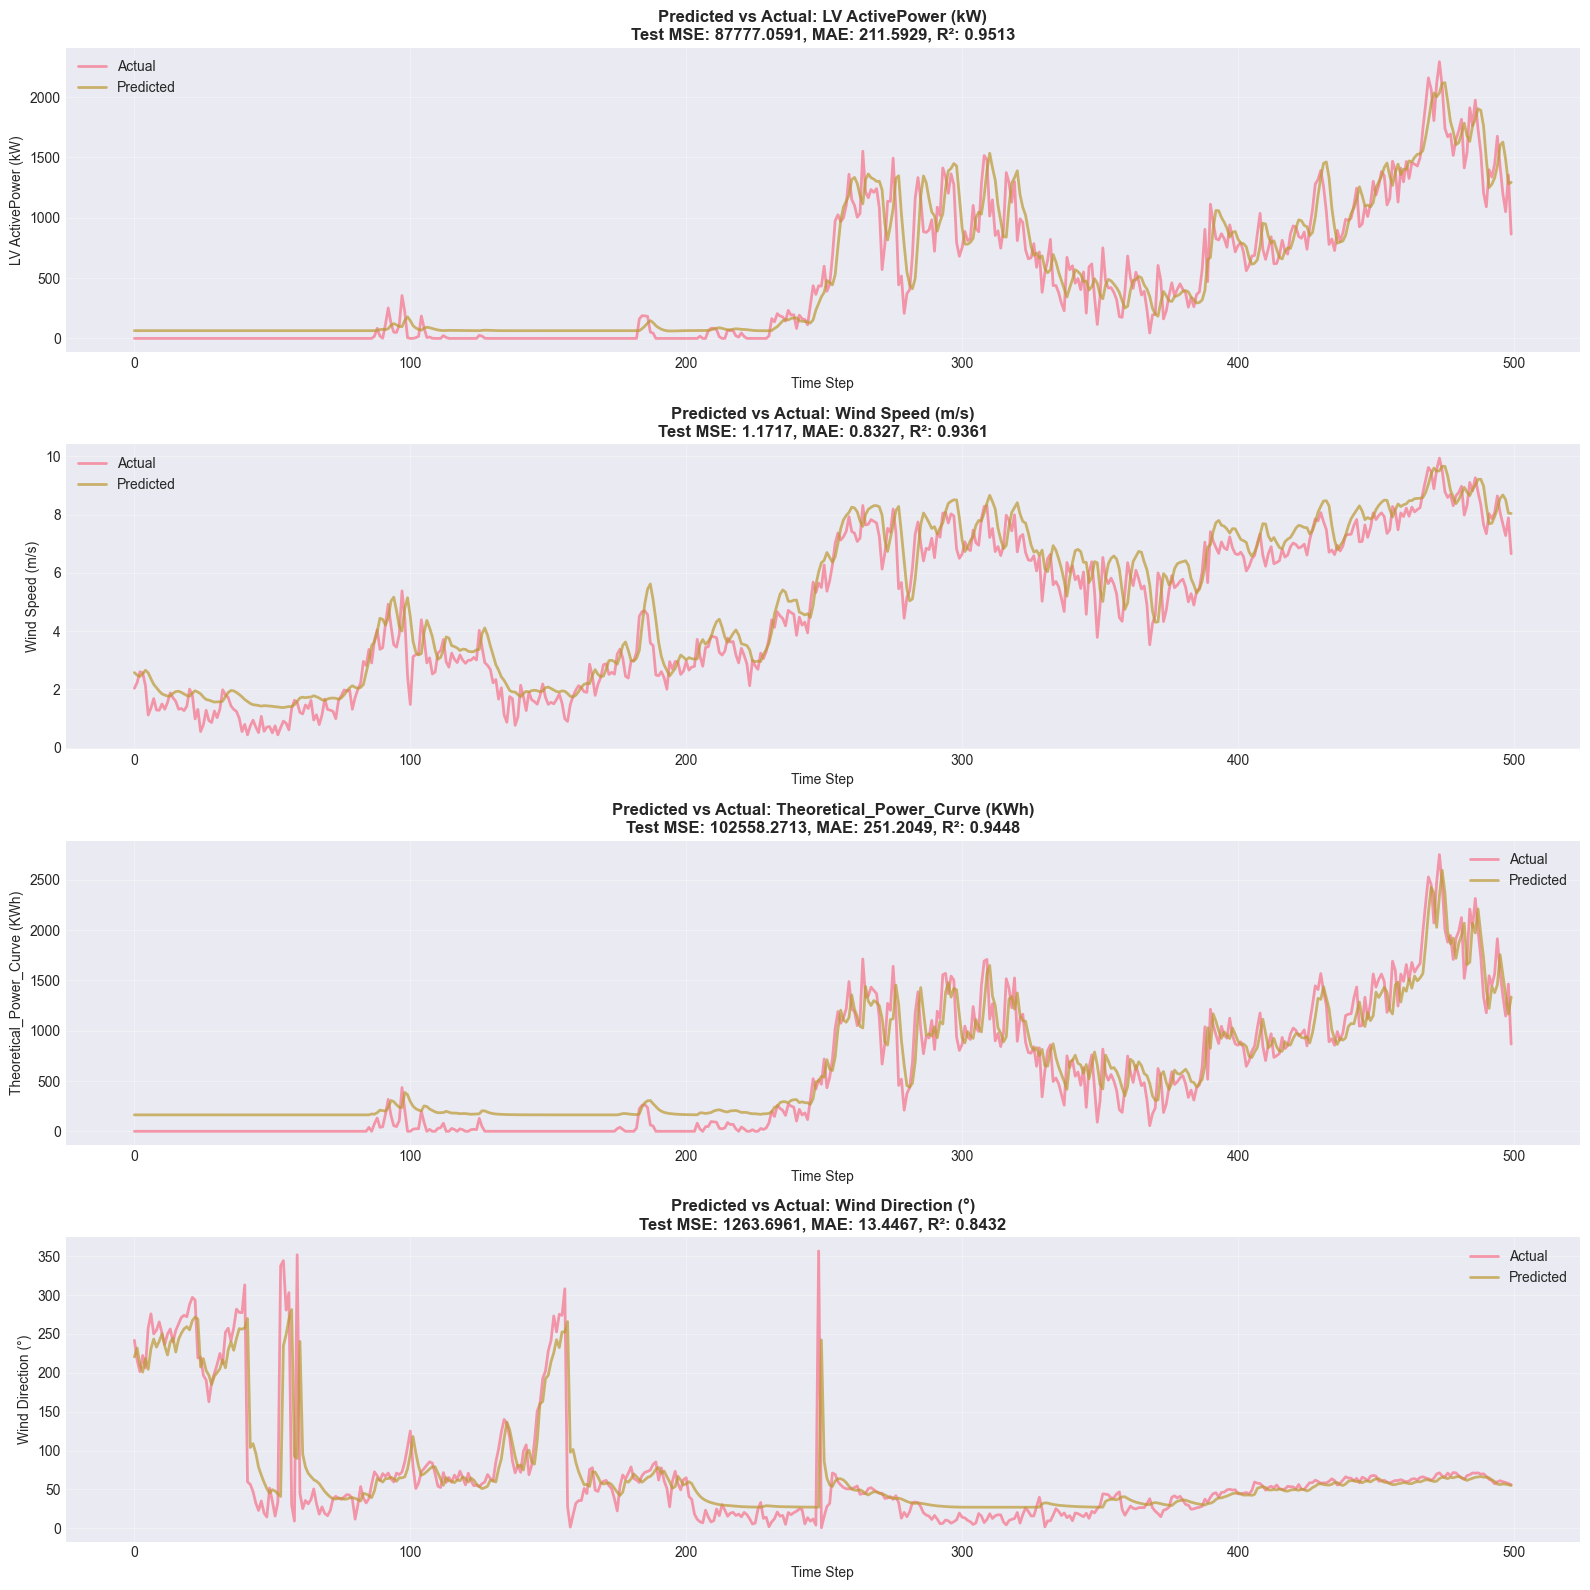

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(16, 16))
for idx, feature in enumerate(forecast_features):
    y_test = results[feature]['y_test']
    y_pred_test = results[feature]['y_pred_test']
    plot_range = slice(0, min(500, len(y_test)))
    axes[idx].plot(y_test[plot_range], label='Actual', linewidth=2, alpha=0.7)
    axes[idx].plot(y_pred_test[plot_range], label='Predicted', linewidth=2, alpha=0.7)
    axes[idx].set_title(f'Predicted vs Actual: {feature}\nTest MSE: {results[feature]["test_mse"]:.4f}, MAE: {results[feature]["test_mae"]:.4f}, R²: {results[feature]["test_r2"]:.4f}', 
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Time Step')
    axes[idx].set_ylabel(feature)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task2_predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

#

## TASK 3: UNSUPERVISED LEARNING (ANOMALY DETECTION)

Power Deviation Statistics:
count    50530.000000
mean      -184.491131
std        427.701555
min      -3600.000000
25%       -194.562692
50%        -66.682623
75%          0.000000
max        598.741011
Name: Power_Deviation, dtype: float64

Deviation Percentage Statistics:
count    50530.000000
mean        -8.628190
std        126.064963
min       -113.265750
25%        -18.345474
50%         -8.212657
75%          0.000000
max       8539.362335
Name: Power_Deviation_Percent, dtype: float64


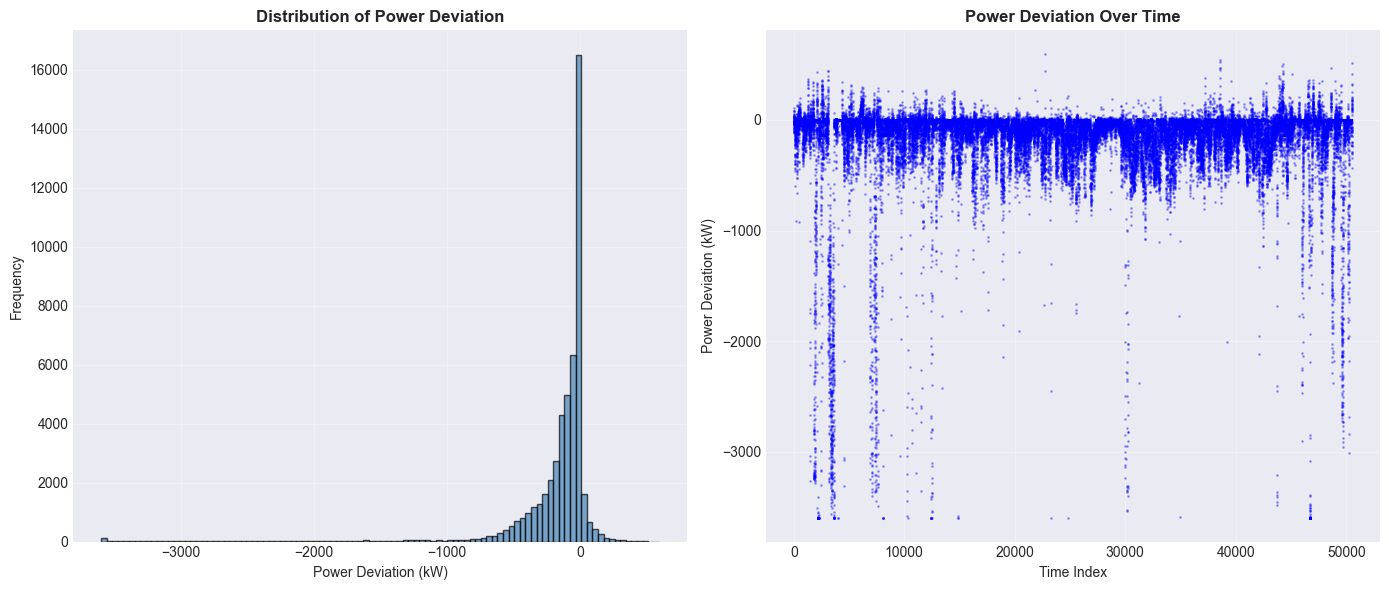

In [12]:
df['Power_Deviation'] = df['LV ActivePower (kW)'] - df['Theoretical_Power_Curve (KWh)']
df['Power_Deviation_Percent'] = (df['Power_Deviation'] / df['Theoretical_Power_Curve (KWh)'].replace(0, 1)) * 100
print("="*80)
print("Power Deviation Statistics:")
print("="*80)
print(df['Power_Deviation'].describe())
print(f"\nDeviation Percentage Statistics:")
print(df['Power_Deviation_Percent'].describe())
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hist(df['Power_Deviation'], bins=100, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Power Deviation (kW)')
plt.ylabel('Frequency')
plt.title('Distribution of Power Deviation', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.scatter(range(len(df)), df['Power_Deviation'], alpha=0.3, s=1, c='blue')
plt.xlabel('Time Index')
plt.ylabel('Power Deviation (kW)')
plt.title('Power Deviation Over Time', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task3_power_deviation.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
anomaly_features = df[['LV ActivePower (kW)', 'Wind Speed (m/s)', 
                        'Theoretical_Power_Curve (KWh)', 'Power_Deviation']].copy()
anomaly_features = anomaly_features.dropna()
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_clean = df.loc[anomaly_features.index].copy()
df_clean['Anomaly_IF'] = iso_forest.fit_predict(anomaly_features)
anomalies_if = df_clean[df_clean['Anomaly_IF'] == -1]
normal_if = df_clean[df_clean['Anomaly_IF'] == 1]
print(f"\nIsolation Forest Results:")
print(f"Total points: {len(df_clean)}")
print(f"Normal points: {len(normal_if)} ({len(normal_if)/len(df_clean)*100:.2f}%)")
print(f"Anomalies detected: {len(anomalies_if)} ({len(anomalies_if)/len(df_clean)*100:.2f}%)")


Isolation Forest Results:
Total points: 50530
Normal points: 48003 (95.00%)
Anomalies detected: 2527 (5.00%)


In [14]:
scaler_dbscan = StandardScaler()
anomaly_features_scaled = scaler_dbscan.fit_transform(anomaly_features)
dbscan = DBSCAN(eps=0.5, min_samples=50)
df_clean['Anomaly_DBSCAN'] = dbscan.fit_predict(anomaly_features_scaled)
anomalies_dbscan = df_clean[df_clean['Anomaly_DBSCAN'] == -1]
normal_dbscan = df_clean[df_clean['Anomaly_DBSCAN'] != -1]
print(f"\nDBSCAN Results:")
print(f"Total points: {len(df_clean)}")
print(f"Normal points: {len(normal_dbscan)} ({len(normal_dbscan)/len(df_clean)*100:.2f}%)")
print(f"Anomalies detected: {len(anomalies_dbscan)} ({len(anomalies_dbscan)/len(df_clean)*100:.2f}%)")
print(f"Number of clusters: {len(set(df_clean['Anomaly_DBSCAN'])) - 1}")


DBSCAN Results:
Total points: 50530
Normal points: 50377 (99.70%)
Anomalies detected: 153 (0.30%)
Number of clusters: 1


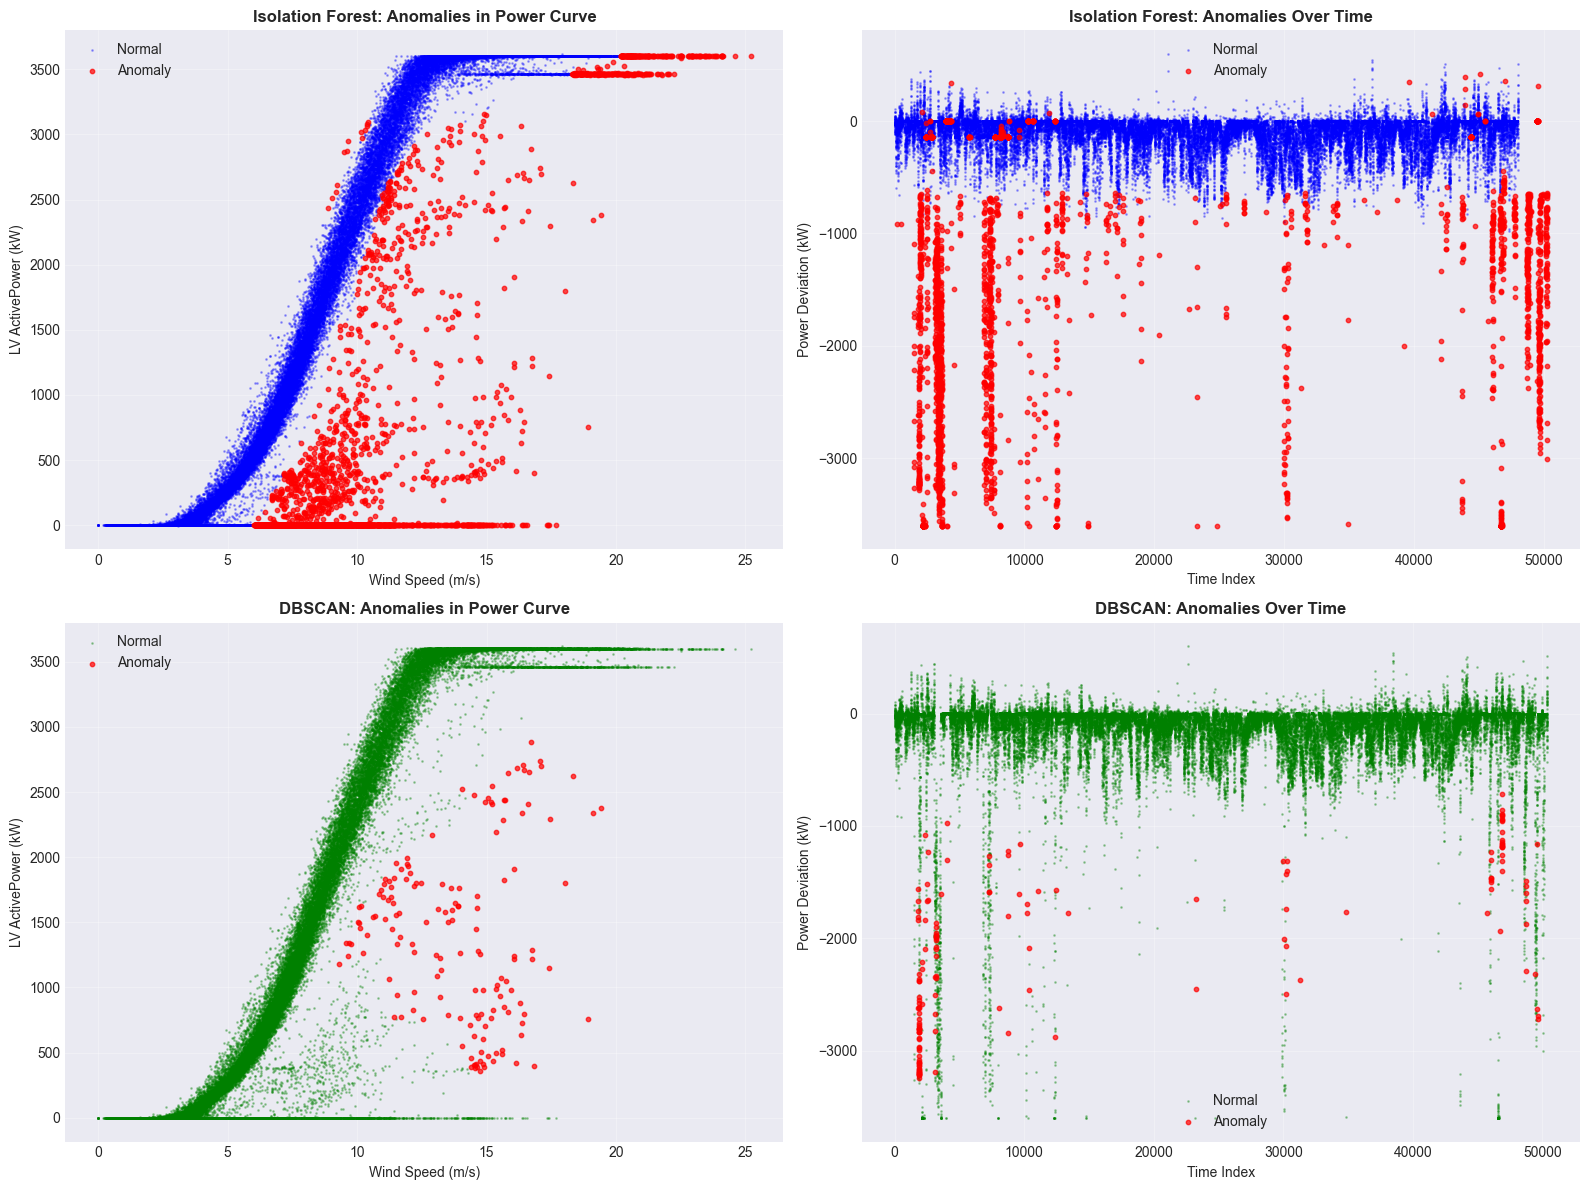

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes[0, 0].scatter(normal_if['Wind Speed (m/s)'], normal_if['LV ActivePower (kW)'], 
                   alpha=0.3, s=1, c='blue', label='Normal')
axes[0, 0].scatter(anomalies_if['Wind Speed (m/s)'], anomalies_if['LV ActivePower (kW)'], 
                   alpha=0.7, s=10, c='red', label='Anomaly')
axes[0, 0].set_xlabel('Wind Speed (m/s)')
axes[0, 0].set_ylabel('LV ActivePower (kW)')
axes[0, 0].set_title('Isolation Forest: Anomalies in Power Curve', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 1].scatter(range(len(normal_if)), normal_if['Power_Deviation'], 
                   alpha=0.3, s=1, c='blue', label='Normal')
axes[0, 1].scatter(anomalies_if.index, anomalies_if['Power_Deviation'], 
                   alpha=0.7, s=10, c='red', label='Anomaly')
axes[0, 1].set_xlabel('Time Index')
axes[0, 1].set_ylabel('Power Deviation (kW)')
axes[0, 1].set_title('Isolation Forest: Anomalies Over Time', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[1, 0].scatter(normal_dbscan['Wind Speed (m/s)'], normal_dbscan['LV ActivePower (kW)'], 
                   alpha=0.3, s=1, c='green', label='Normal')
axes[1, 0].scatter(anomalies_dbscan['Wind Speed (m/s)'], anomalies_dbscan['LV ActivePower (kW)'], 
                   alpha=0.7, s=10, c='red', label='Anomaly')
axes[1, 0].set_xlabel('Wind Speed (m/s)')
axes[1, 0].set_ylabel('LV ActivePower (kW)')
axes[1, 0].set_title('DBSCAN: Anomalies in Power Curve', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 1].scatter(range(len(normal_dbscan)), normal_dbscan['Power_Deviation'], 
                   alpha=0.3, s=1, c='green', label='Normal')
axes[1, 1].scatter(anomalies_dbscan.index, anomalies_dbscan['Power_Deviation'], 
                   alpha=0.7, s=10, c='red', label='Anomaly')
axes[1, 1].set_xlabel('Time Index')
axes[1, 1].set_ylabel('Power Deviation (kW)')
axes[1, 1].set_title('DBSCAN: Anomalies Over Time', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task3_anomaly_detection.png', dpi=300, bbox_inches='tight')
plt.show()


Underperformance Analysis:
Total underperforming points: 8504 (16.83%)

Underperforming points statistics:
       LV ActivePower (kW)  Wind Speed (m/s)  Theoretical_Power_Curve (KWh)  \
count          8504.000000       8504.000000                    8504.000000   
mean            488.235532          6.793978                    1112.025215   
std             640.807550          2.530043                    1057.596560   
min              -0.071800          3.844952                     100.153992   
25%              60.432866          4.768371                     281.068687   
50%             249.634300          6.073224                     648.968549   
75%             588.558762          8.331623                    1725.233578   
max            2869.673096         19.433180                    3600.000000   

       Power_Deviation  
count      8504.000000  
mean       -623.789683  
std         866.632053  
min       -3600.000000  
25%        -714.699977  
50%        -202.204272  
75%  

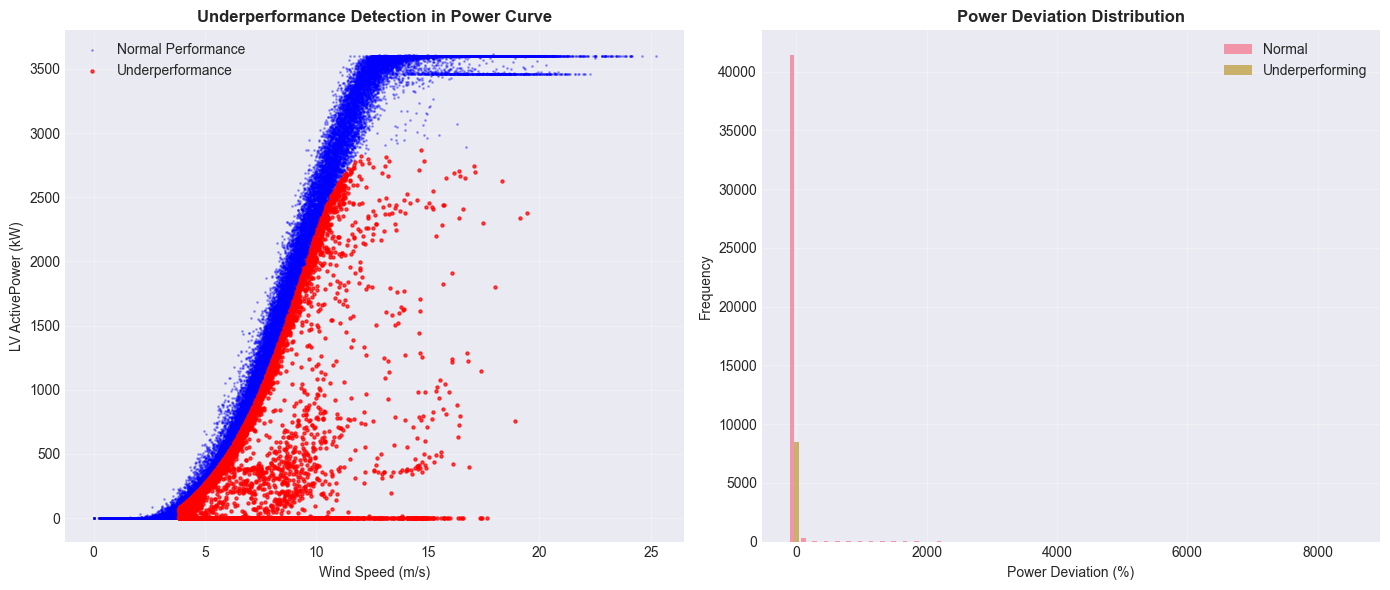

In [16]:
df_clean['Underperformance'] = (df_clean['LV ActivePower (kW)'] < 0.8 * df_clean['Theoretical_Power_Curve (KWh)']) & (df_clean['Theoretical_Power_Curve (KWh)'] > 100)
underperforming = df_clean[df_clean['Underperformance'] == True]
print(f"="*80)
print(f"\nUnderperformance Analysis:")
print(f"="*80)
print(f"Total underperforming points: {len(underperforming)} ({len(underperforming)/len(df_clean)*100:.2f}%)")
print(f"\nUnderperforming points statistics:")
print(underperforming[['LV ActivePower (kW)', 'Wind Speed (m/s)', 
                       'Theoretical_Power_Curve (KWh)', 'Power_Deviation']].describe())
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(df_clean[~df_clean['Underperformance']]['Wind Speed (m/s)'], 
           df_clean[~df_clean['Underperformance']]['LV ActivePower (kW)'], 
           alpha=0.3, s=1, c='blue', label='Normal Performance')
plt.scatter(underperforming['Wind Speed (m/s)'], underperforming['LV ActivePower (kW)'], 
           alpha=0.7, s=5, c='red', label='Underperformance')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('LV ActivePower (kW)')
plt.title('Underperformance Detection in Power Curve', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.hist([df_clean[~df_clean['Underperformance']]['Power_Deviation_Percent'], 
          underperforming['Power_Deviation_Percent']], 
         bins=50, label=['Normal', 'Underperforming'], alpha=0.7)
plt.xlabel('Power Deviation (%)')
plt.ylabel('Frequency')
plt.title('Power Deviation Distribution', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task3_underperformance.png', dpi=300, bbox_inches='tight')
plt.show()

#

## TASK 4: AI TURBINE PERFORMANCE SCORE GENERATOR

#### Task 4.1 & Task 4.2 - Calculate Performance Score and Scale the score 

In [17]:
def calculate_performance_score(actual_power, theoretical_power):
    if theoretical_power == 0 or theoretical_power < 10:
        return 50  
    ratio = actual_power / theoretical_power
    score = min(ratio * 100, 100)
    score = max(score, 0)
    return score
df_clean['Performance_Score'] = df_clean.apply(
    lambda row: calculate_performance_score(
        row['LV ActivePower (kW)'], 
        row['Theoretical_Power_Curve (KWh)']
    ), 
    axis=1
)
print("="*80)
print("Performance Score Statistics:")
print("="*80)
print(df_clean['Performance_Score'].describe())

Performance Score Statistics:
count    50530.000000
mean        75.104694
std         28.197272
min          0.000000
25%         50.000000
50%         85.915548
75%         96.094620
max        100.000000
Name: Performance_Score, dtype: float64


### Task 4.3 - Categorize Turbine State


Turbine State Distribution:
Turbine_State
Good        31606
Poor        13288
Moderate     5636
Name: count, dtype: int64

Percentages:
Turbine_State
Good        62.548981
Poor        26.297249
Moderate    11.153770
Name: count, dtype: float64


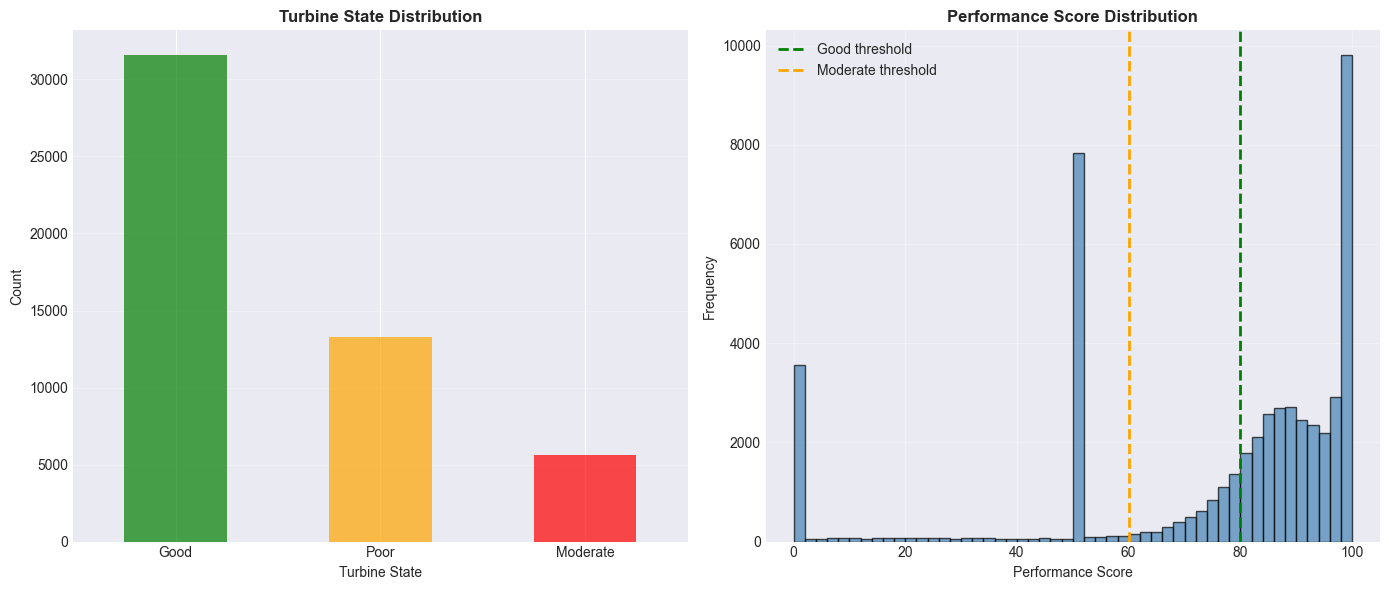

In [18]:
def categorize_turbine_state(score):
    if score >= 80:
        return 'Good'
    elif score >= 60:
        return 'Moderate'
    else:
        return 'Poor'
df_clean['Turbine_State'] = df_clean['Performance_Score'].apply(categorize_turbine_state)
state_counts = df_clean['Turbine_State'].value_counts()
print(f"\nTurbine State Distribution:")
print("="*50)
print(state_counts)
print(f"\nPercentages:")
print(state_counts / len(df_clean) * 100)
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
state_counts.plot(kind='bar', color=['green', 'orange', 'red'], alpha=0.7)
plt.xlabel('Turbine State')
plt.ylabel('Count')
plt.title('Turbine State Distribution', fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.subplot(1, 2, 2)
plt.hist(df_clean['Performance_Score'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(80, color='green', linestyle='--', linewidth=2, label='Good threshold')
plt.axvline(60, color='orange', linestyle='--', linewidth=2, label='Moderate threshold')
plt.xlabel('Performance Score')
plt.ylabel('Frequency')
plt.title('Performance Score Distribution', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task4_performance_scores.png', dpi=300, bbox_inches='tight')
plt.show()

### Task 4.4 - Generate Automated Suggestions

In [19]:
def generate_suggestion(score, state, wind_speed, power_deviation):
    suggestions = []
    if state == 'Poor':
        suggestions.append("URGENT: Turbine underperforming significantly")
        suggestions.append("→ Schedule immediate inspection")
        suggestions.append("→ Check blade condition and orientation")
        suggestions.append("→ Verify gearbox and generator functionality")
    elif state == 'Moderate':
        suggestions.append("⚡ ATTENTION: Moderate performance detected")
        suggestions.append("→ Plan maintenance within 1-2 weeks")
        suggestions.append("→ Monitor power output trends")
    else:  
        suggestions.append("✓ NORMAL: Turbine operating efficiently")
        suggestions.append("→ Continue regular monitoring")
    if wind_speed < 3:
        suggestions.append("→ Low wind conditions - performance expected to be low")
    elif wind_speed > 25:
        suggestions.append("→ High wind speeds detected - check for cut-out activation")
    if abs(power_deviation) > 500:
        suggestions.append("→ Large power deviation detected - investigate cause")
    return "\n".join(suggestions)
print("="*80)
print("Automated Suggestions:")
print("="*80)
for state in ['Good', 'Moderate', 'Poor']:
    sample = df_clean[df_clean['Turbine_State'] == state].head(1)
    if len(sample) > 0:
        row = sample.iloc[0]
        print(f"\n{state.upper()} Performance Example:")
        print(f"  Performance Score: {row['Performance_Score']:.2f}")
        print(f"  Wind Speed: {row['Wind Speed (m/s)']:.2f} m/s")
        print(f"  Power Deviation: {row['Power_Deviation']:.2f} kW")
        print(f"\nSuggestions:")
        print(generate_suggestion(row['Performance_Score'], row['Turbine_State'], 
                                 row['Wind Speed (m/s)'], row['Power_Deviation']))
        print("-"*80)

Automated Suggestions:

GOOD Performance Example:
  Performance Score: 91.29
  Wind Speed: 5.31 m/s
  Power Deviation: -36.28 kW

Suggestions:
✓ NORMAL: Turbine operating efficiently
→ Continue regular monitoring
--------------------------------------------------------------------------------

MODERATE Performance Example:
  Performance Score: 78.38
  Wind Speed: 5.22 m/s
  Power Deviation: -84.52 kW

Suggestions:
⚡ ATTENTION: Moderate performance detected
→ Plan maintenance within 1-2 weeks
→ Monitor power output trends
--------------------------------------------------------------------------------

POOR Performance Example:
  Performance Score: 58.38
  Wind Speed: 9.07 m/s
  Power Deviation: -911.81 kW

Suggestions:
URGENT: Turbine underperforming significantly
→ Schedule immediate inspection
→ Check blade condition and orientation
→ Verify gearbox and generator functionality
→ Large power deviation detected - investigate cause
-------------------------------------------------------

#

## TASK 5: CNN FOR IMAGE CLASSIFICATION

In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import multilabel_confusion_matrix, precision_score, recall_score, f1_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm
import cv2

In [21]:
CSV_PATH = r"D:\Novintix\multilabel_modified\multilabel_classification(2).csv"
IMG_DIR = r"D:\Novintix\multilabel_modified\images"
BATCH_SIZE = 32
EPOCHS = 10
NUM_CLASSES = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ["Motorcycle", "Track", "boat", "Bus", "Cycle", "Person",
               "Desert", "Mountains", "sea", "Sunset", "Trees",
               "sitar", "ektara", "Flutes", "tabla", "Harmonium"]

In [22]:
class MultiLabelDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.data = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.labels = dataframe.iloc[:, 2:].values.astype("float32")
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        img_name = self.data.iloc[idx, 0]
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(self.labels[idx])
        return image, label, img_name

In [23]:
df = pd.read_csv(CSV_PATH)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
def filter_images(df, img_dir):
    mask = df.iloc[:, 0].apply(lambda x: os.path.exists(os.path.join(img_dir, x)))
    return df[mask].reset_index(drop=True)
train_df = filter_images(train_df, IMG_DIR)
val_df = filter_images(val_df, IMG_DIR)
print(f"Train: {len(train_df)}, Val: {len(val_df)}")

Train: 6264, Val: 1579


In [24]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
train_dataset = MultiLabelDataset(train_df, IMG_DIR, transform)
val_dataset = MultiLabelDataset(val_df, IMG_DIR, transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [25]:
model = models.resnet18(pretrained=True)
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)
model = model.to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:09<00:00, 4.87MB/s]


In [26]:
def train_epoch(model, loader):
    model.train()
    running_loss = 0
    for images, labels, _ in tqdm(loader, desc="Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)
def validate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels, _ in tqdm(loader, desc="Validation"):
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            all_preds.append(preds.cpu())
            all_labels.append(labels)
    return torch.cat(all_preds), torch.cat(all_labels)

In [27]:
history = {'train_loss': [], 'val_loss': []}
for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_preds, val_labels = validate(model, val_loader)
    val_loss = criterion(model(torch.randn(1, 3, 224, 224).to(DEVICE)), 
                         torch.randn(1, NUM_CLASSES).to(DEVICE)).item()
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}")
torch.save(model.state_dict(), "multilabel_model.pth")
print("Training completed!")

Validation: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:47<00:00,  1.06it/s]


Epoch 1/10 - Train Loss: 0.1757


Validation: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:45<00:00,  1.09it/s]


Epoch 2/10 - Train Loss: 0.0798


Validation: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:33<00:00,  1.49it/s]


...

Epoch 8/10 - Train Loss: 0.0276


Validation: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:34<00:00,  1.45it/s]


Epoch 9/10 - Train Loss: 0.0275


Validation: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [00:34<00:00,  1.45it/s]

Epoch 10/10 - Train Loss: 0.0273
Training completed!
